In [ ]:
!pip install -q pywavelets tensorflow scipy matplotlib mne

import numpy as np
import matplotlib.pyplot as plt
import pywt
import os
import re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.signal import butter, filtfilt
import cv2
from PIL import Image
import mne
mne.set_log_level('ERROR')

print("Библиотеки импортированы")
print(f"TensorFlow: {tf.__version__}")

Библиотеки импортированы
TensorFlow: 2.20.0


In [ ]:
# Создание директорий для изображений и моделей
!mkdir -p /content/images/seizure
!mkdir -p /content/images/nonseizure
!mkdir -p /content/models

# Проверка загруженных файлов
edf_files = [f for f in os.listdir('/content') if f.endswith('.edf')]
print("Найденные EDF файлы:")
for f in edf_files:
    size_mb = os.path.getsize(f'/content/{f}') / (1024*1024)
    print(f"  {f} ({size_mb:.1f} МБ)")

# Проверка файла аннотаций
if os.path.exists('/content/chb08-summary.txt'):
    print("\nФайл аннотаций chb08-summary.txt найден")
else:
    print("\nФайл аннотаций не найден!")

Найденные EDF файлы:
  chb08_11.edf (40.4 МБ)
  chb08_05.edf (40.4 МБ)
  chb08_02.edf (40.4 МБ)

Файл аннотаций chb08-summary.txt найден


In [ ]:
def parse_summary(filepath):
    """Извлечение информации о приступах из summary-файла"""
    text = open(filepath).read()
    seizure_events = {}

    # Разделение текста по блокам File Name
    blocks = re.split(r'File Name:\s*', text)

    for block in blocks[1:]:
        first_line = block.split('\n', 1)[0].strip()
        if not first_line.endswith('.edf'):
            continue

        # Поиск всех времен начала и конца приступов
        starts = re.findall(r'Seizure(?:\s+\d+)?\s+Start Time:\s*(\d+)\s*seconds', block)
        ends = re.findall(r'Seizure(?:\s+\d+)?\s+End Time:\s*(\d+)\s*seconds', block)

        events = list(zip(map(int, starts), map(int, ends)))
        if events:
            seizure_events[first_line] = events

    return seizure_events

# Парсинг аннотаций
events = parse_summary('/content/chb08-summary.txt')

print("Обнаруженные приступы:")
for fname, evs in events.items():
    for s, e in evs:
        print(f"  {fname}: {s}-{e} сек (длительность {e-s} с)")

# Определение файлов с приступами и без
all_edf_files = [f for f in os.listdir('/content') if f.endswith('.edf')]
seizure_files_list = list(events.keys())
nonseizure_files_list = [f for f in all_edf_files if f not in seizure_files_list]

print(f"\nФайлы с приступами: {seizure_files_list}")
print(f"Файлы без приступов: {nonseizure_files_list}")

Обнаруженные приступы:
  chb08_02.edf: 2670-2841 сек (длительность 171 с)
  chb08_05.edf: 2856-3046 сек (длительность 190 с)
  chb08_11.edf: 2988-3122 сек (длительность 134 с)
  chb08_13.edf: 2417-2577 сек (длительность 160 с)
  chb08_21.edf: 2083-2347 сек (длительность 264 с)

Файлы с приступами: ['chb08_02.edf', 'chb08_05.edf', 'chb08_11.edf', 'chb08_13.edf', 'chb08_21.edf']
Файлы без приступов: []


In [ ]:
def extract_segments(edf_path, seizure_intervals, window_sec=4.0):
    """
    Извлечение окон ЭЭГ из файла.
    Возвращает сегменты с приступом и без.
    """
    # Загрузка EDF файла
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
    sfreq = raw.info['sfreq']

    # Фильтрация сигнала (ФНЧ 60 Гц)
    raw.filter(l_freq=None, h_freq=60.0, verbose=False)

    # Усреднение всех каналов в один сигнал
    data = raw.get_data()
    signal = data.mean(axis=0)

    n_samples = signal.shape[0]
    win = int(window_sec * sfreq)

    # Создание маски приступа
    is_seizure = np.zeros(n_samples, dtype=bool)
    for s, e in seizure_intervals:
        start_idx = int(s * sfreq)
        end_idx = int(e * sfreq)
        if end_idx > n_samples:
            end_idx = n_samples
        is_seizure[start_idx:end_idx] = True

    seizure_segs, normal_segs = [], []

    # Нарезка сигнала на окна без перекрытия
    for i in range(0, n_samples - win + 1, win):
        seg = signal[i:i + win]
        frac = is_seizure[i:i + win].mean()

        # Окно полностью внутри приступа
        if frac == 1.0:
            seizure_segs.append(seg)
        # Окно полностью вне приступа
        elif frac == 0.0:
            normal_segs.append(seg)

    return seizure_segs, normal_segs, sfreq

print("Функция извлечения сегментов готова")

Функция извлечения сегментов готова


In [ ]:
WINDOW_SEC = 4.0   # Длина окна в секундах
TARGET = 60         # Целевое количество сегментов каждого класса

all_seizure_segments = []
all_normal_segments = []
sfreq_global = None

# Обработка файлов с приступами
for fname in seizure_files_list:
    if fname not in all_edf_files:
        continue

    filepath = f'/content/{fname}'
    intervals = events.get(fname, [])

    print(f"Обработка {fname}...")

    sez, norm, sfreq = extract_segments(filepath, intervals, WINDOW_SEC)

    if sfreq is not None:
        sfreq_global = sfreq

    all_seizure_segments.extend(sez)
    all_normal_segments.extend(norm)

    print(f"  Получено: приступ={len(sez)}, норма={len(norm)}")

print(f"\nЧастота дискретизации: {sfreq_global} Гц")
print(f"Всего сегментов: приступ={len(all_seizure_segments)}, норма={len(all_normal_segments)}")

# Балансировка классов (случайный выбор нужного количества)
rng = np.random.default_rng(42)

if len(all_seizure_segments) > TARGET:
    idx = rng.choice(len(all_seizure_segments), size=TARGET, replace=False)
    all_seizure_segments = [all_seizure_segments[i] for i in idx]

if len(all_normal_segments) > TARGET:
    idx = rng.choice(len(all_normal_segments), size=TARGET, replace=False)
    all_normal_segments = [all_normal_segments[i] for i in idx]

print(f"После балансировки: приступ={len(all_seizure_segments)}, норма={len(all_normal_segments)}")

Обработка chb08_02.edf...


/tmp/ipykernel_24192/1087376478.py:7: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


  Получено: приступ=42, норма=856
Обработка chb08_05.edf...


/tmp/ipykernel_24192/1087376478.py:7: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


  Получено: приступ=47, норма=852
Обработка chb08_11.edf...


/tmp/ipykernel_24192/1087376478.py:7: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


  Получено: приступ=33, норма=866

Частота дискретизации: 256.0 Гц
Всего сегментов: приступ=122, норма=2574
После балансировки: приступ=60, норма=60


In [ ]:
# Очистка папок с изображениями
import shutil
for folder in ['/content/images/seizure', '/content/images/nonseizure']:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# Параметры вейвлет-преобразования
WAVELET = 'cmor1.5-1.0'   # Комплексный вейвлет Морле
N_SCALES = 80              # Количество масштабов
F_MIN, F_MAX = 1, 60       # Диапазон частот (Гц)

def make_scalogram(signal, sfreq):
    """Вычисление скейлограммы (CWT) и перевод в дБ"""
    fc = pywt.central_frequency(WAVELET)
    freqs = np.logspace(np.log10(F_MIN), np.log10(F_MAX), N_SCALES)
    scales = fc * sfreq / freqs
    coef, _ = pywt.cwt(signal, scales, WAVELET, sampling_period=1.0/sfreq)
    power = np.abs(coef) ** 2
    return 10.0 * np.log10(power + 1e-12)

def estimate_vmin_vmax(segments, sfreq, q_low=1, q_high=99):
    """Оценка глобального диапазона яркости по процентилям"""
    pool = []
    for seg in segments:
        pool.append(make_scalogram(seg, sfreq).ravel())
    pool = np.concatenate(pool)
    return float(np.percentile(pool, q_low)), float(np.percentile(pool, q_high))

def save_scalogram_png(signal, sfreq, out_path, vmin, vmax, img_size=64):
    """Сохранение скейлограммы как PNG-изображения"""
    sg = make_scalogram(signal, sfreq)
    # Нормализация в диапазон [0, 1]
    sg = np.clip((sg - vmin) / (vmax - vmin + 1e-9), 0, 1)

    # Применение цветовой карты magma
    magma = plt.get_cmap('magma')
    rgb = (magma(sg)[:, :, :3] * 255).astype(np.uint8)

    # Переворот и масштабирование
    img = Image.fromarray(rgb).transpose(Image.FLIP_TOP_BOTTOM)
    img = img.resize((img_size, img_size), Image.BILINEAR)
    img.save(out_path)

# Оценка глобального диапазона яркости
all_segments = all_seizure_segments + all_normal_segments
print("Оценка диапазона яркости...")
VMIN, VMAX = estimate_vmin_vmax(all_segments, sfreq_global)
print(f"VMIN={VMIN:.1f}, VMAX={VMAX:.1f}")

# Создание изображений для класса "приступ"
print(f"\nСоздание изображений для класса 'приступ'...")
for i, seg in enumerate(all_seizure_segments):
    path = f'/content/images/seizure/seizure_{i:03d}.png'
    save_scalogram_png(seg, sfreq_global, path, VMIN, VMAX)

# Создание изображений для класса "норма"
print(f"Создание изображений для класса 'норма'...")
for i, seg in enumerate(all_normal_segments):
    path = f'/content/images/nonseizure/normal_{i:03d}.png'
    save_scalogram_png(seg, sfreq_global, path, VMIN, VMAX)

print(f"\nГотово! Создано изображений:")
print(f"  seizure: {len(os.listdir('/content/images/seizure'))}")
print(f"  normal:  {len(os.listdir('/content/images/nonseizure'))}")

Оценка диапазона яркости...
VMIN=-119.8, VMAX=-72.3

Создание изображений для класса 'приступ'...
Создание изображений для класса 'норма'...

Готово! Создано изображений:
  seizure: 60
  normal:  60


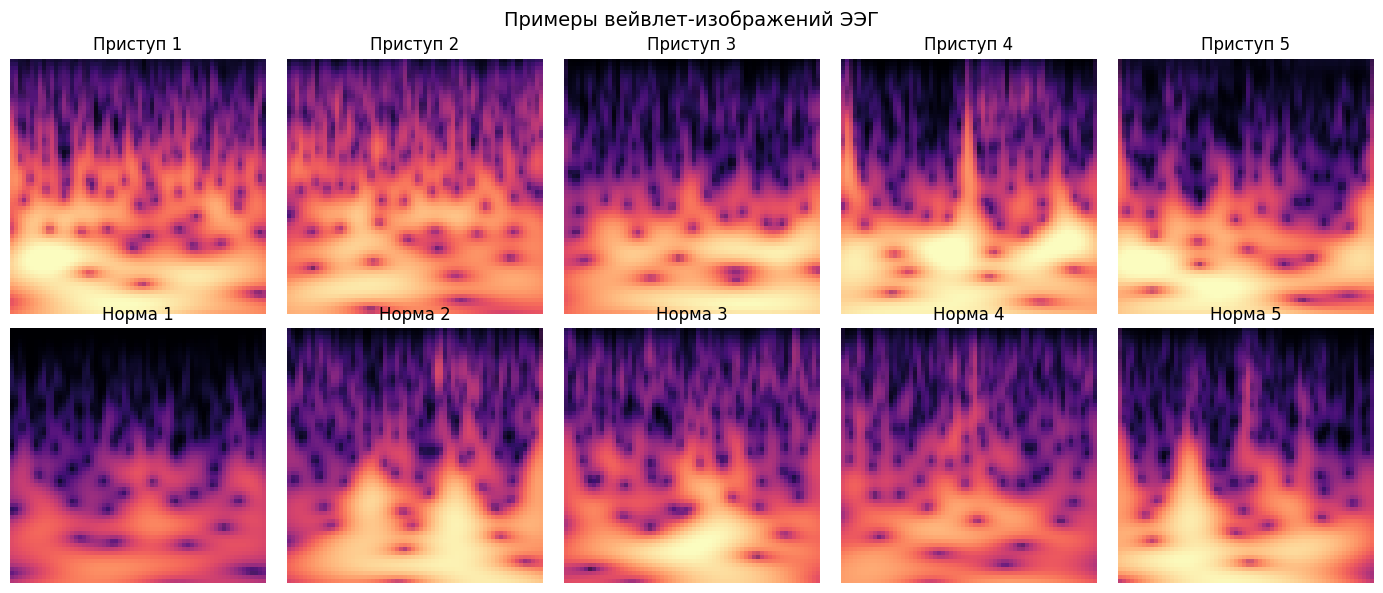

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

seizure_files = sorted(os.listdir('/content/images/seizure'))[:5]
for i, fname in enumerate(seizure_files):
    img = Image.open(f'/content/images/seizure/{fname}')
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Приступ {i+1}')
    axes[0, i].axis('off')

normal_files = sorted(os.listdir('/content/images/nonseizure'))[:5]
for i, fname in enumerate(normal_files):
    img = Image.open(f'/content/images/nonseizure/{fname}')
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Норма {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Примеры вейвлет-изображений ЭЭГ', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def load_images_from_dir(directory, label, img_size=64):
    """Загрузка изображений из папки с присвоением метки класса"""
    images, labels = [], []
    files = sorted(os.listdir(directory))
    for filename in files:
        if filename.endswith('.png'):
            img_path = os.path.join(directory, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

# Загрузка изображений
seizure_images, seizure_labels = load_images_from_dir('/content/images/seizure', 1)
normal_images, normal_labels = load_images_from_dir('/content/images/nonseizure', 0)

# Уравнивание количества
min_count = min(len(seizure_images), len(normal_images))
seizure_images = seizure_images[:min_count]
seizure_labels = seizure_labels[:min_count]
normal_images = normal_images[:min_count]
normal_labels = normal_labels[:min_count]

# Объединение данных
X = np.concatenate([seizure_images, normal_images], axis=0)
y = np.concatenate([seizure_labels, normal_labels], axis=0)

# Перемешивание
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

# Разделение на train/val/test (60%/20%/20%)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, stratify=y_tv, random_state=42
)

print(f"Всего изображений: {len(X)}")
print(f"  С приступами: {len(seizure_images)}")
print(f"  Без приступов: {len(normal_images)}")
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Всего изображений: 120
  С приступами: 60
  Без приступов: 60
Train: (76, 64, 64, 3)
Val:   (20, 64, 64, 3)
Test:  (24, 64, 64, 3)


In [ ]:
# Сброс состояния Keras
tf.keras.backend.clear_session()

def build_cnn(input_shape=(64, 64, 3)):
    """Построение свёрточной нейронной сети"""
    model = models.Sequential([
        layers.Input(shape=input_shape, name='scalogram'),
        layers.Rescaling(1.0 / 255.0),

        # Свёрточный блок 1
        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Свёрточный блок 2
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Свёрточный блок 3
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Классификатор
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid', name='p_seizure'),
    ], name='EEG_CNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model

# Создание модели
model = build_cnn()
model.summary()

# Колбэк ранней остановки
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1,
)

# Обучение модели
print("\nОбучение модели...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=2,
)

# Сохранение модели
model.save('/content/models/cnn_eeg_classifier.keras')
print("Модель сохранена")

Model: "EEG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_seizure (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,905 (1.10 MB)

 Trainable params: 287,905 (1.10 MB)

 Non-trainable params: 0 (0.00 B)


Обучение модели...
Epoch 1/50
5/5 - 7s - 1s/step - accuracy: 0.4737 - loss: 0.6967 - val_accuracy: 0.5000 - val_loss: 0.6895
Epoch 2/50
5/5 - 0s - 23ms/step - accuracy: 0.5132 - loss: 0.6955 - val_accuracy: 0.7000 - val_loss: 0.6820
Epoch 3/50
5/5 - 0s - 24ms/step - accuracy: 0.5263 - loss: 0.6857 - val_accuracy: 0.5000 - val_loss: 0.6780
Epoch 4/50
5/5 - 0s - 24ms/step - accuracy: 0.6579 - loss: 0.6552 - val_accuracy: 0.6500 - val_loss: 0.6580
Epoch 5/50
5/5 - 0s - 22ms/step - accuracy: 0.6711 - loss: 0.6405 - val_accuracy: 0.6500 - val_loss: 0.6448
Epoch 6/50
5/5 - 0s - 23ms/step - accuracy: 0.6974 - loss: 0.5657 - val_accuracy: 0.7500 - val_loss: 0.5684
Epoch 7/50
5/5 - 0s - 21ms/step - accuracy: 0.8158 - loss: 0.4867 - val_accuracy: 0.6500 - val_loss: 0.5804
Epoch 8/50
5/5 - 0s - 23ms/step - accuracy: 0.8553 - loss: 0.4810 - val_accuracy: 0.7500 - val_loss: 0.6043
Epoch 9/50
5/5 - 0s - 21ms/step - accuracy: 0.8158 - loss: 0.4435 - val_accuracy: 0.7500 - val_loss: 0.6025
Epoch 10/5

Точность на тестовой выборке: 0.8750
Функция потерь на тестовой выборке: 0.3119

Отчёт о классификации:
              precision    recall  f1-score   support

       Норма      0.846     0.917     0.880        12
     Приступ      0.909     0.833     0.870        12

    accuracy                          0.875        24
   macro avg      0.878     0.875     0.875        24
weighted avg      0.878     0.875     0.875        24



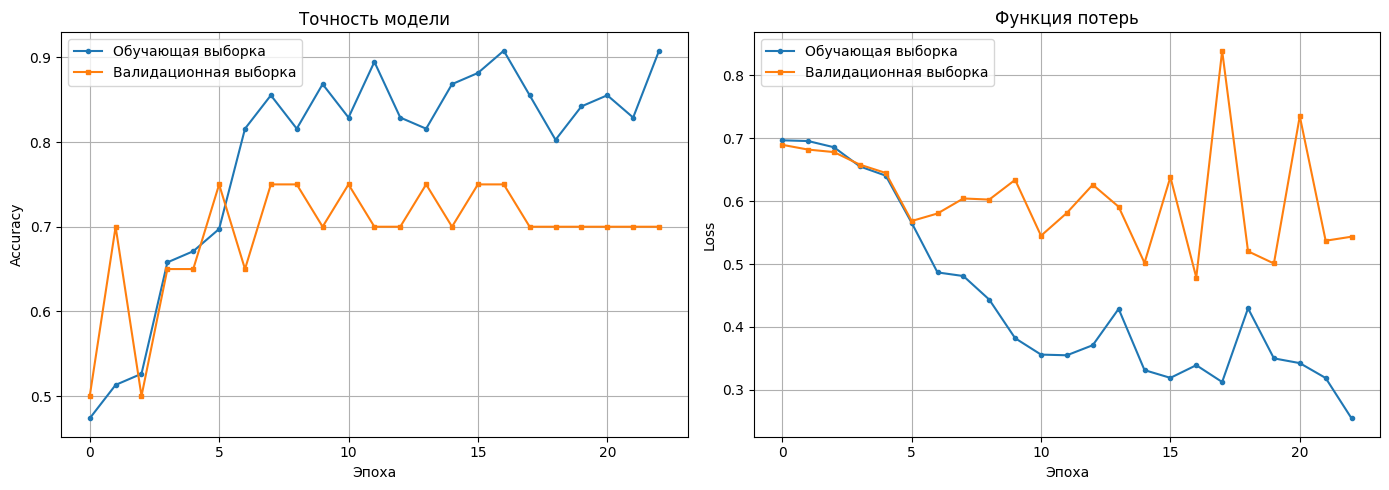

In [ ]:
# Оценка на тестовой выборке
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Точность на тестовой выборке: {test_acc:.4f}")
print(f"Функция потерь на тестовой выборке: {test_loss:.4f}")

# Предсказания
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("\nОтчёт о классификации:")
print(classification_report(y_test, y_pred,
                           target_names=['Норма', 'Приступ'], digits=3))

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Обучающая выборка', marker='o', ms=3)
axes[0].plot(history.history['val_accuracy'], label='Валидационная выборка', marker='s', ms=3)
axes[0].set_title('Точность модели')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Обучающая выборка', marker='o', ms=3)
axes[1].plot(history.history['val_loss'], label='Валидационная выборка', marker='s', ms=3)
axes[1].set_title('Функция потерь')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

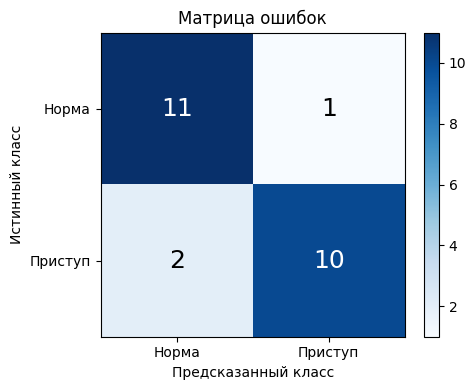

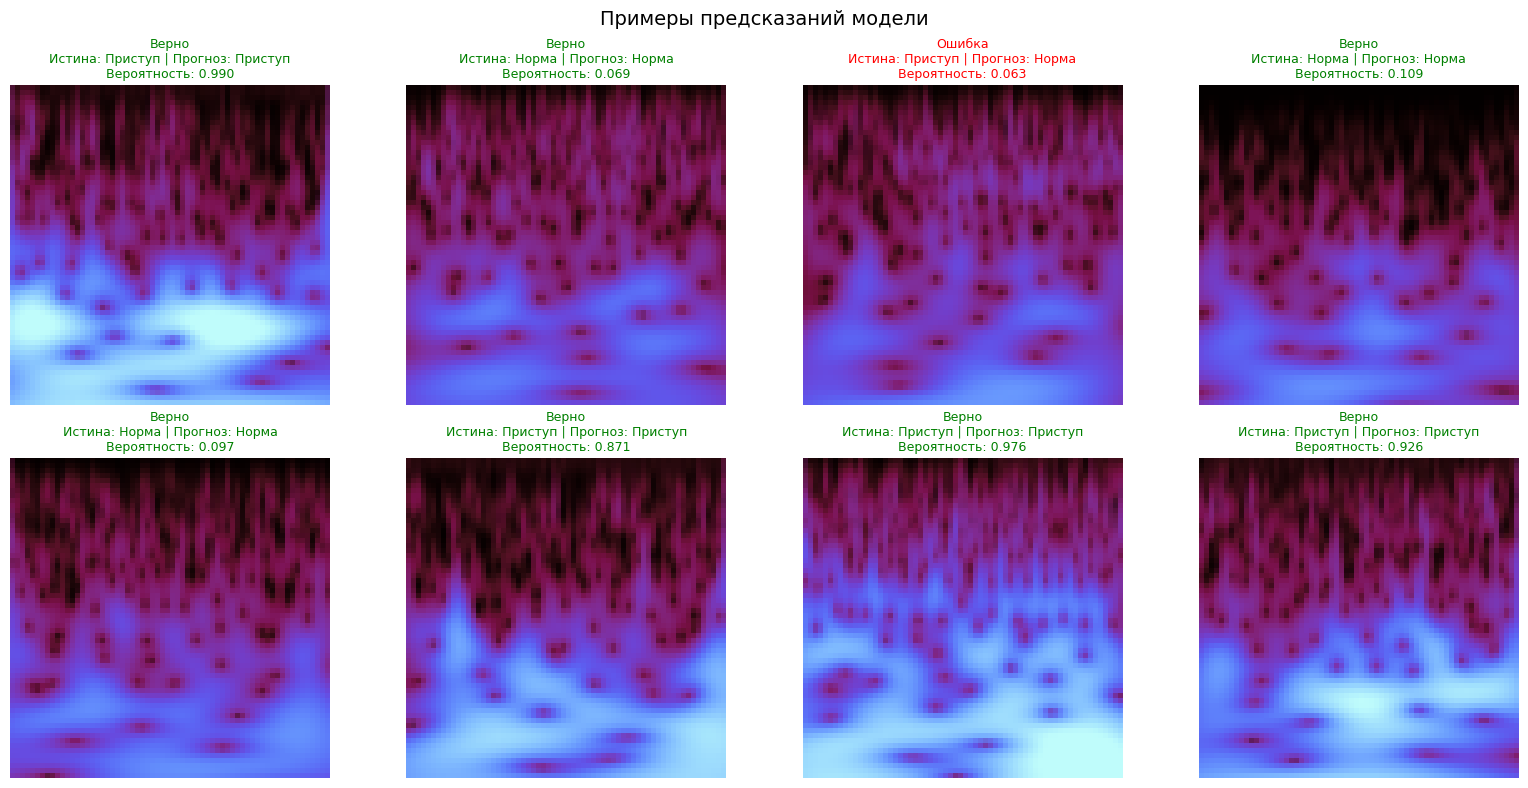

In [ ]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Матрица ошибок')
plt.colorbar()
plt.xticks([0, 1], ['Норма', 'Приступ'])
plt.yticks([0, 1], ['Норма', 'Приступ'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

# Примеры предсказаний
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = np.random.choice(len(X_test), size=8, replace=False)

for ax, idx in zip(axes.flat, indices):
    img = X_test[idx]
    true_label = 'Приступ' if y_test[idx] == 1 else 'Норма'
    pred_prob = y_prob[idx]
    pred_label = 'Приступ' if pred_prob >= 0.5 else 'Норма'
    correct = 'Верно' if true_label == pred_label else 'Ошибка'
    color = 'green' if correct == 'Верно' else 'red'

    ax.imshow(img.astype('uint8'))
    ax.set_title(f'{correct}\nИстина: {true_label} | Прогноз: {pred_label}\nВероятность: {pred_prob:.3f}',
                color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Примеры предсказаний модели', fontsize=14)
plt.tight_layout()
plt.show()